# Importamos las bibliotecas y cargamos los datos

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import math

In [2]:
df = pd.read_csv("HW02_data_champ.csv", delimiter = ";" ,header = 0)
df

,PID,CHOSEN,GENDER,AGE,WORK,GRAD,RELIG,STUDENT,MARRIED,PURCH,...,SMELL_HM,COLOR_DEL,COLOR_GOS,COLOR_VCP,COLOR_HM,ADV_DEL,ADV_GOS,ADV_VCP,ADV_HM,UNO
0,1,2,1,44,1,1,4,1,1,2,...,4,4,4,4,4,4,3,1,3,1
1,2,2,1,28,2,1,1,1,1,1,...,5,2,5,4,5,4,3,3,5,1
2,3,2,2,46,2,1,1,2,3,2,...,5,4,5,4,4,4,3,3,5,1
3,4,2,2,24,1,1,1,3,1,1,...,4,5,3,4,4,1,4,3,5,1
4,5,1,2,41,2,1,1,1,1,1,...,4,4,4,5,3,3,4,1,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2645,2646,4,2,32,2,3,2,2,3,2,...,4,5,4,4,4,5,3,4,4,1
2646,2647,2,1,34,2,2,1,3,1,1,...,4,3,4,4,3,3,4,3,3,1
2647,2648,3,2,46,1,1,2,1,1,2,...,5,4,4,5,5,3,3,3,3,1
2648,2649,2,1,34,2,1,1,2,1,2,...,4,4,4,5,1,3,3,3,3,1


In [3]:
# df['PRICE_DEL'] = df['PRICE_DEL'].astype(int)
# df['PRICE_GOS'] = df['PRICE_GOS'].astype(int)
# df['PRICE_VCP'] = df['PRICE_VCP'].astype(int)
# df['PRICE_HM'] = df['PRICE_HM'].astype(int)

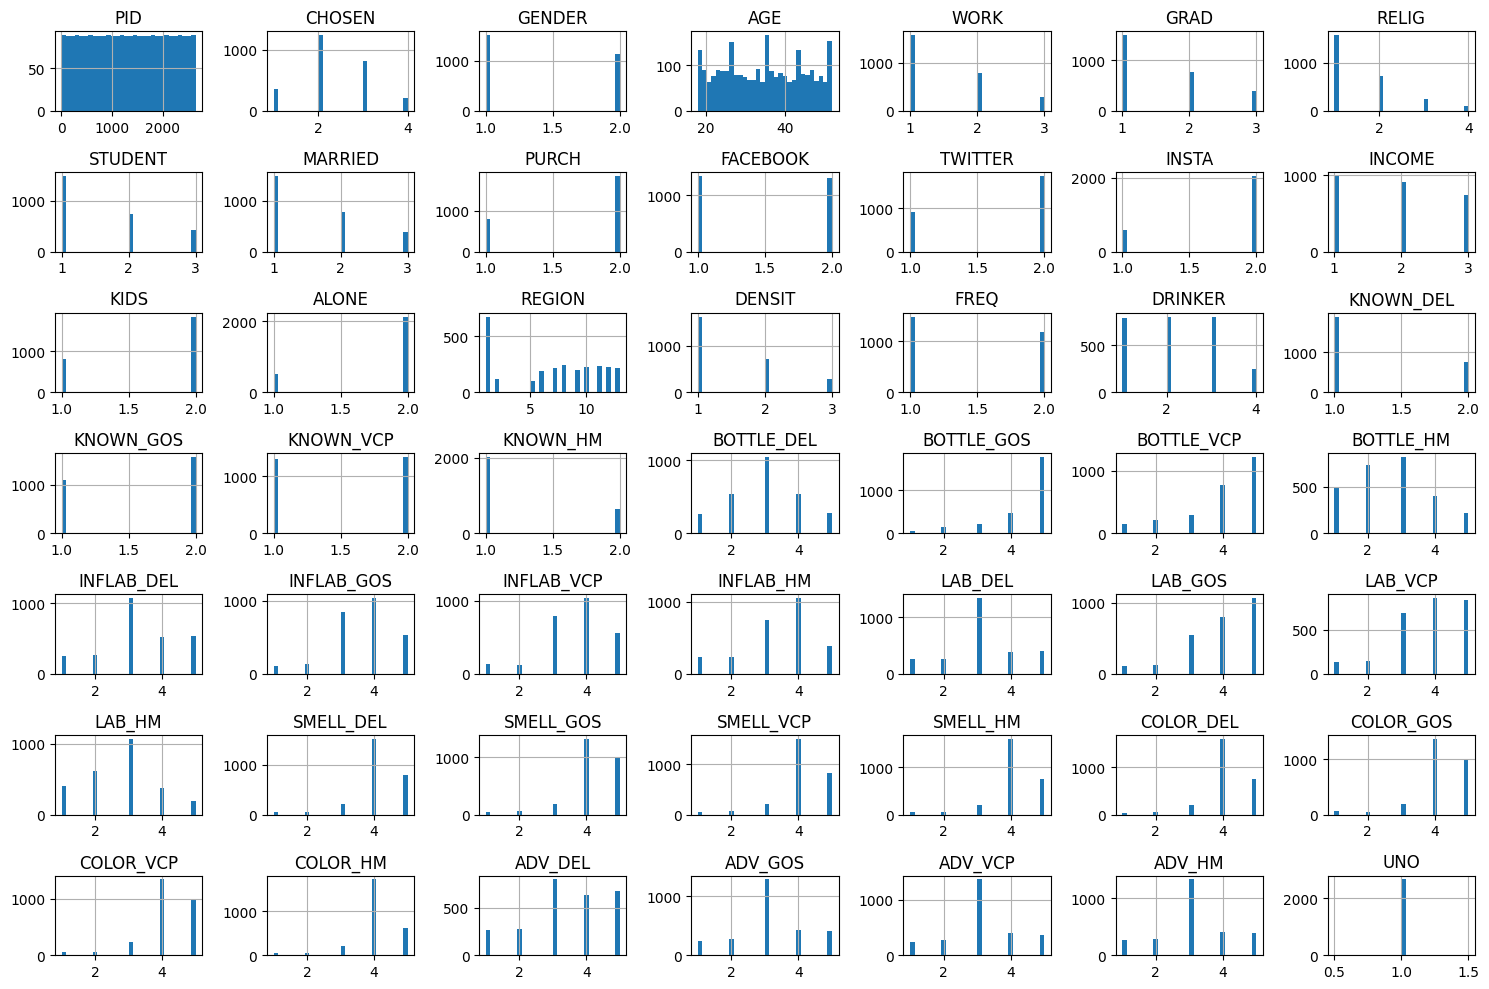

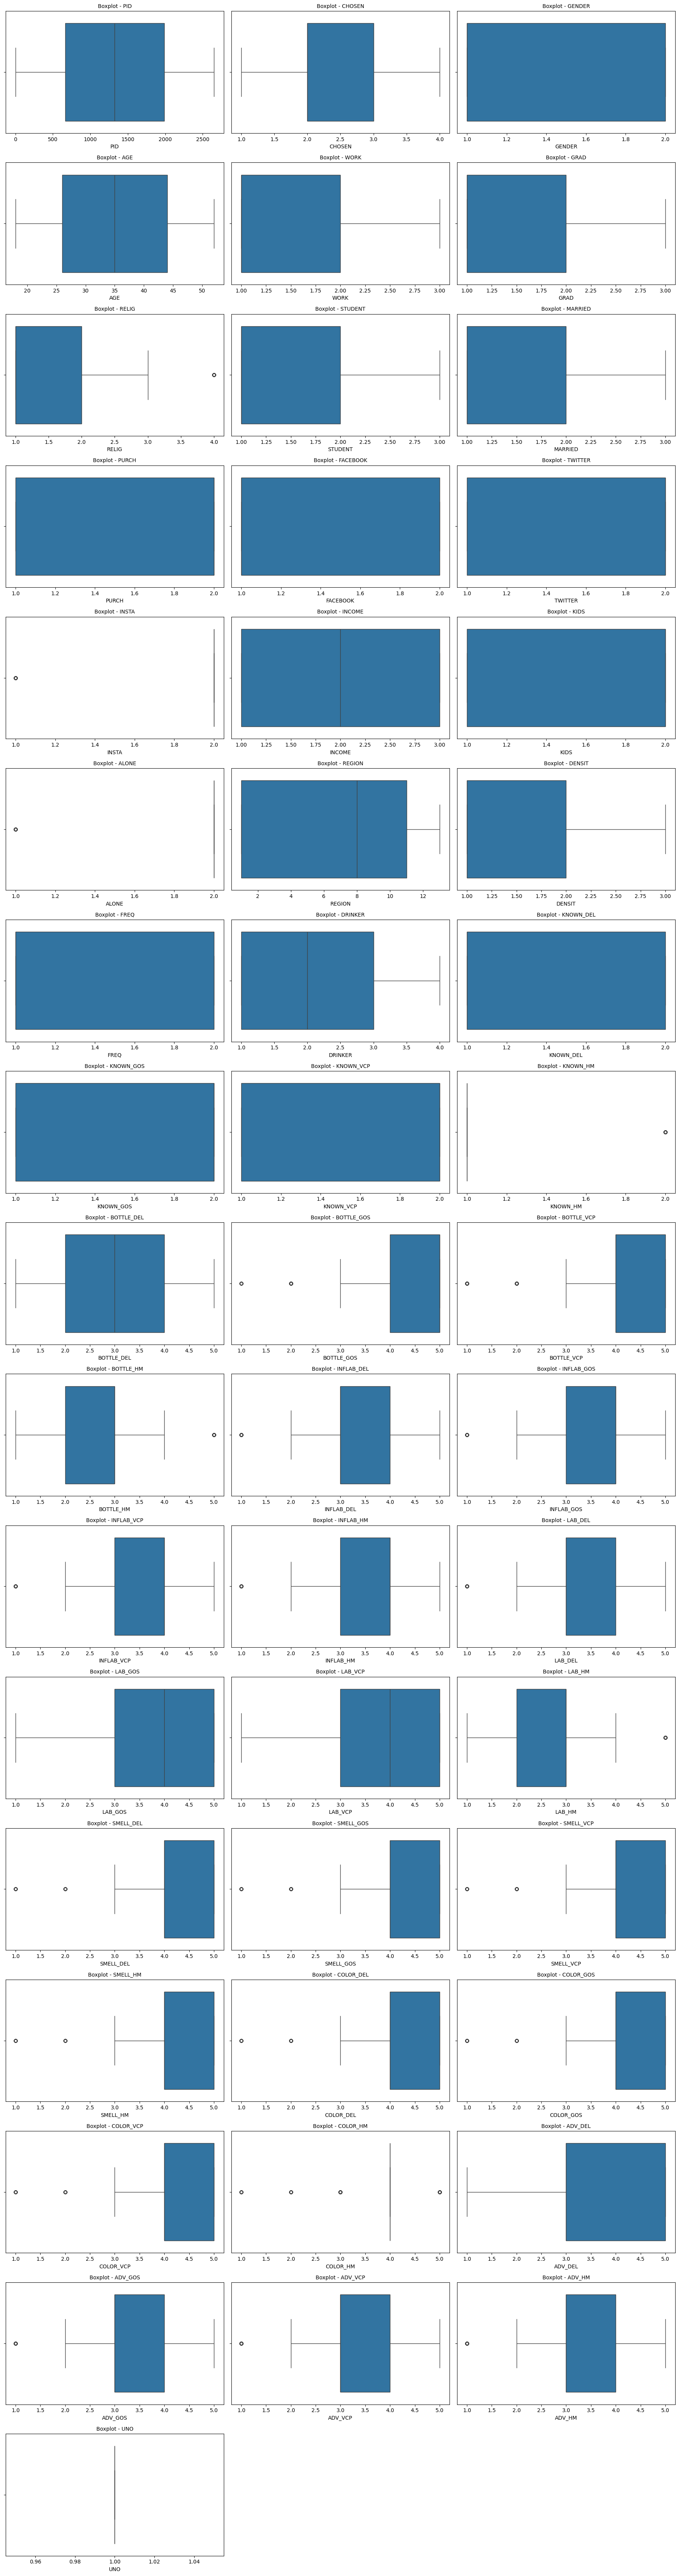

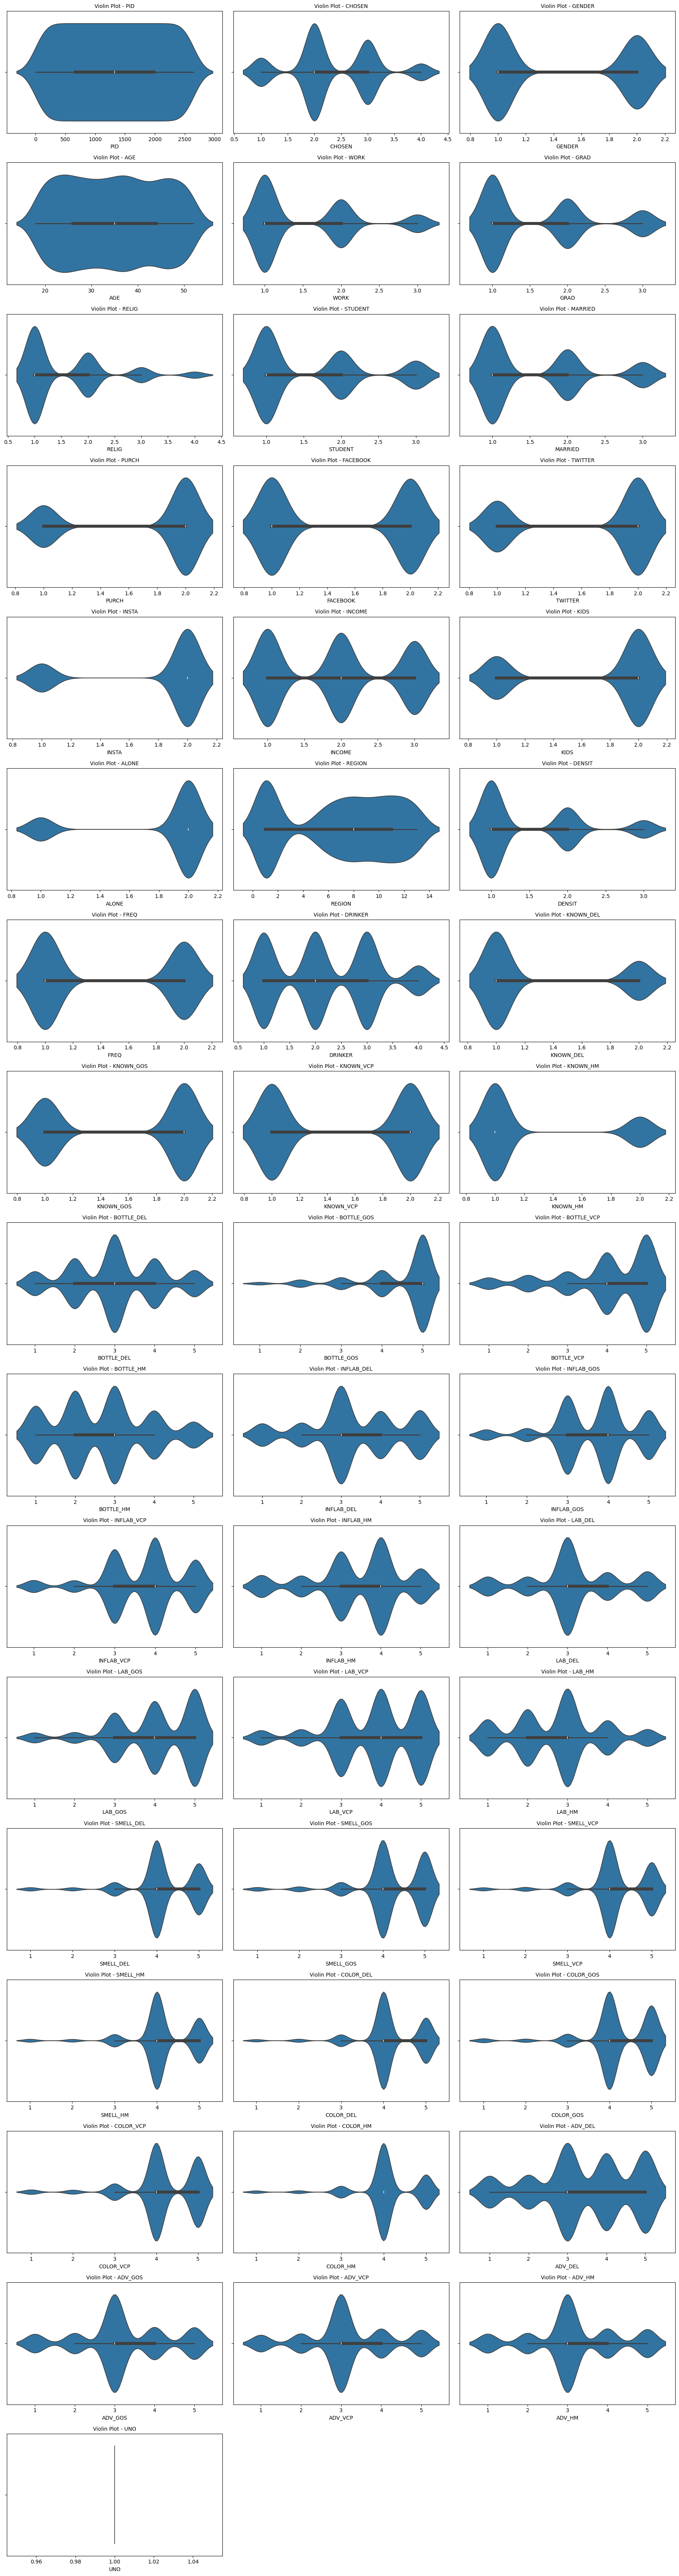

In [4]:
# Excluir columnas binarias del DataFrame
df_non_binary = df

# 1. Histogramas para ver distribuciones (excluyendo columnas binarias)
df_non_binary.hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()

# 2. Boxplots organizados de 3 en 3 por fila
numeric_cols = df_non_binary.select_dtypes(include=[np.number]).columns

# Configurar diseño de los subplots para los boxplots
cols_per_row = 3
total = len(numeric_cols)
rows = math.ceil(total / cols_per_row)

# Crear figura con subplots para boxplots
fig, axes = plt.subplots(rows, cols_per_row, figsize=(6 * cols_per_row, 4 * rows))
axes = axes.flatten()  # Aplanar para fácil acceso

# Dibujar cada boxplot
for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df_non_binary[col], ax=axes[i])
    axes[i].set_title(f'Boxplot - {col}', fontsize=10)

# Ocultar subplots vacíos (si los hay)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# 3. Violin plots organizados de 3 en 3 por fila
# Crear figura con subplots para los violin plots
fig, axes = plt.subplots(rows, cols_per_row, figsize=(6 * cols_per_row, 4 * rows))
axes = axes.flatten()  # Aplanar para fácil acceso

# Dibujar cada violin plot
for i, col in enumerate(numeric_cols):
    sns.violinplot(x=df_non_binary[col], ax=axes[i])
    axes[i].set_title(f'Violin Plot - {col}', fontsize=10)

# Ocultar subplots vacíos (si los hay)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [5]:
# Calificaciones de los atributos para todas las marcas
columns_to_check = ['BOTTLE_DEL', 'INFLAB_DEL', 'LAB_DEL', 'SMELL_DEL', 'COLOR_DEL', 'ADV_DEL',
                    'BOTTLE_GOS', 'INFLAB_GOS', 'LAB_GOS', 'SMELL_GOS', 'COLOR_GOS', 'ADV_GOS',
                    'BOTTLE_VCP', 'INFLAB_VCP', 'LAB_VCP', 'SMELL_VCP', 'COLOR_VCP', 'ADV_VCP',
                    'BOTTLE_HM', 'INFLAB_HM', 'LAB_HM', 'SMELL_HM', 'COLOR_HM', 'ADV_HM']

# Calcular estadísticas descriptivas de las calificaciones para todas las marcas
desc_stats = df[columns_to_check].describe()

# Mostrar estadísticas descriptivas
print("Estadísticas descriptivas de las calificaciones de todas las marcas:")
print(desc_stats)

# Precios de todas las marcas
df_prices = df[['PRICE_DEL', 'PRICE_GOS', 'PRICE_VCP', 'PRICE_HM']]

# Mostrar estadísticas de precios
print("\nEstadísticas de los precios de todas las marcas:")
print(df_prices.describe())



Estadísticas descriptivas de las calificaciones de todas las marcas:
        BOTTLE_DEL   INFLAB_DEL      LAB_DEL    SMELL_DEL    COLOR_DEL  \
count  2650.000000  2650.000000  2650.000000  2650.000000  2650.000000   
mean      3.018491     3.316604     3.152830     4.123774     4.127925   
std       1.103222     1.178223     1.108515     0.792900     0.742811   
min       1.000000     1.000000     1.000000     1.000000     1.000000   
25%       2.000000     3.000000     3.000000     4.000000     4.000000   
50%       3.000000     3.000000     3.000000     4.000000     4.000000   
75%       4.000000     4.000000     4.000000     5.000000     5.000000   
max       5.000000     5.000000     5.000000     5.000000     5.000000   

           ADV_DEL   BOTTLE_GOS   INFLAB_GOS      LAB_GOS    SMELL_GOS  ...  \
count  2650.000000  2650.000000  2650.000000  2650.000000  2650.000000  ...   
mean      3.445283     4.425283     3.647547     3.980755     4.203774  ...   
std       1.249321     0.96

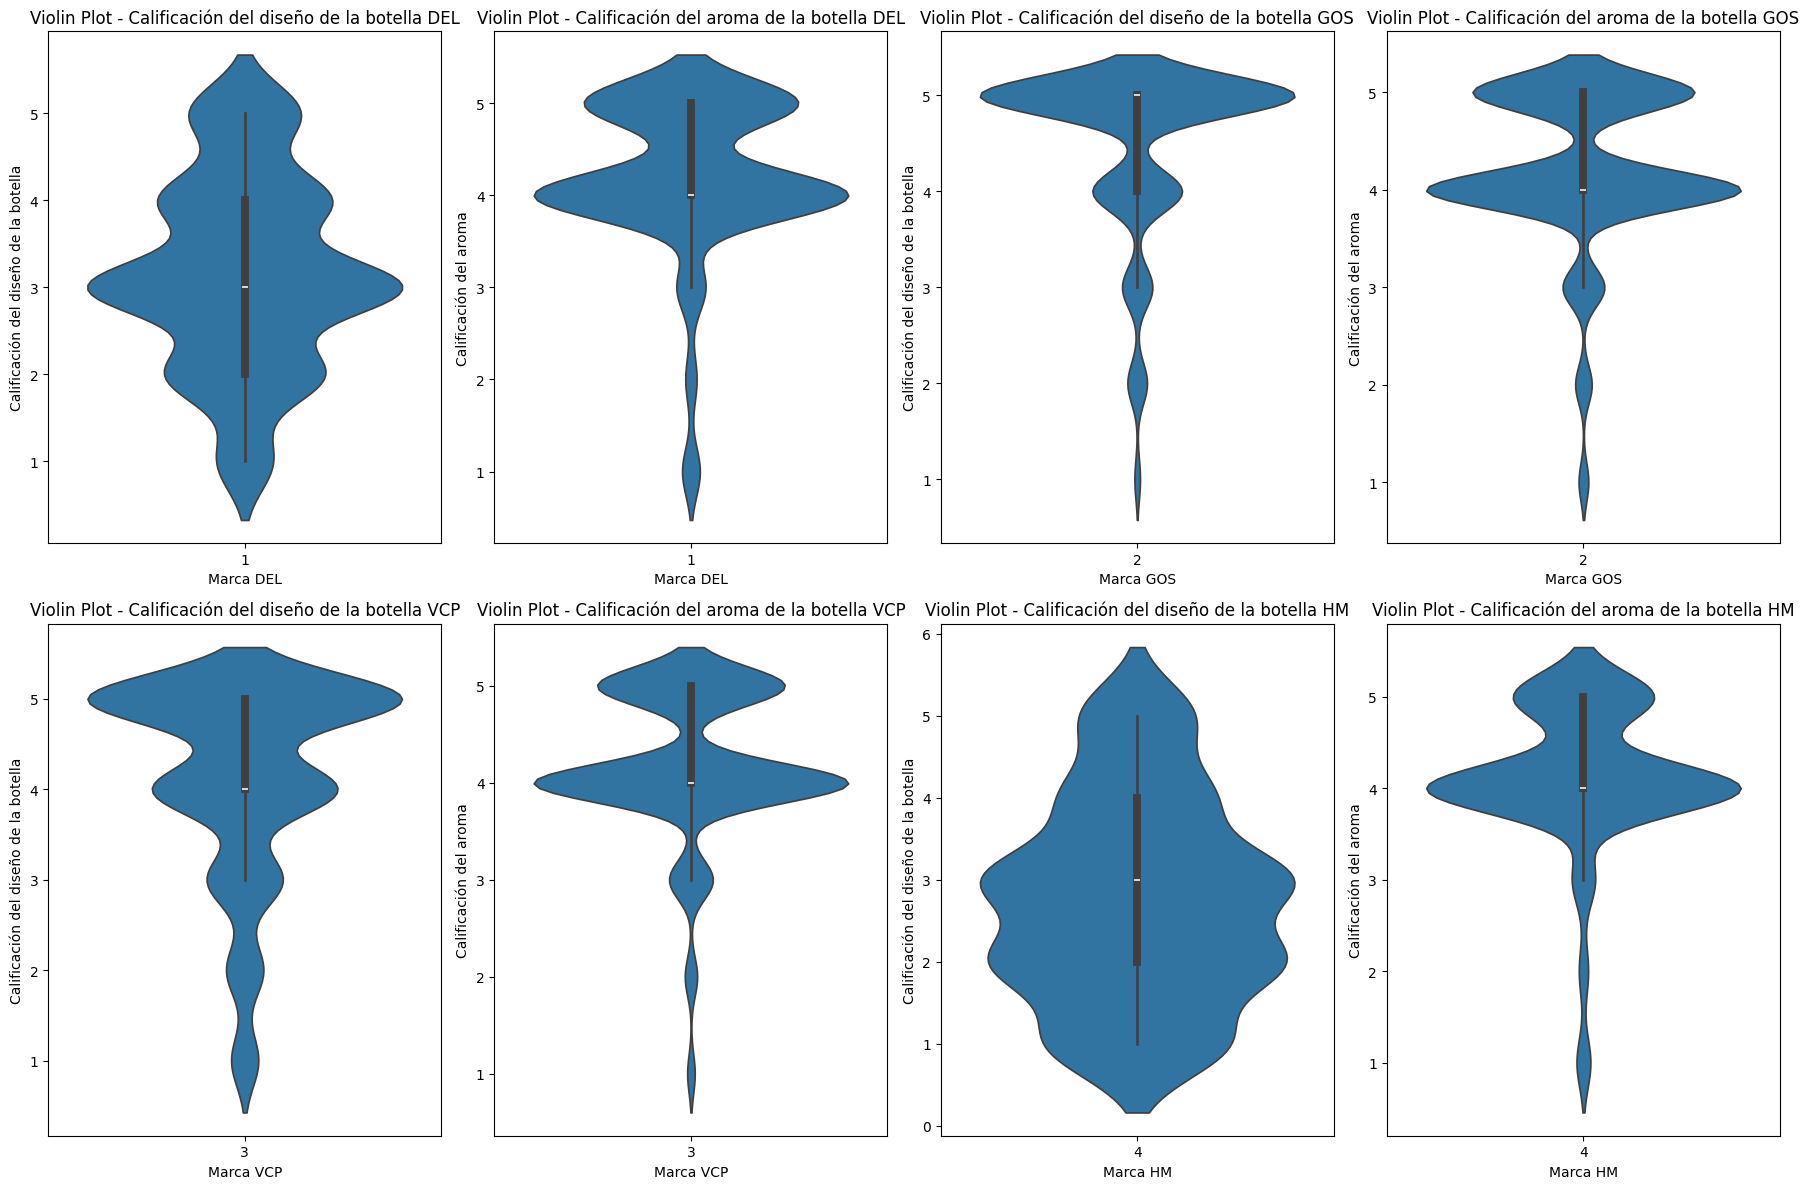

In [6]:
# Crear una figura con subgráficos
fig, axes = plt.subplots(2, 4, figsize=(18, 12))  # 2 filas y 4 columnas
axes = axes.flatten()  # Aplanar para fácil acceso

# Violin plots para la marca DEL
sns.violinplot(x='CHOSEN', y='BOTTLE_DEL', data=df[df['CHOSEN'] == 1], ax=axes[0])
axes[0].set_title('Violin Plot - Calificación del diseño de la botella DEL')
axes[0].set_xlabel('Marca DEL')
axes[0].set_ylabel('Calificación del diseño de la botella')

sns.violinplot(x='CHOSEN', y='SMELL_DEL', data=df[df['CHOSEN'] == 1], ax=axes[1])
axes[1].set_title('Violin Plot - Calificación del aroma de la botella DEL')
axes[1].set_xlabel('Marca DEL')
axes[1].set_ylabel('Calificación del aroma')

# Violin plots para la marca GOS
sns.violinplot(x='CHOSEN', y='BOTTLE_GOS', data=df[df['CHOSEN'] == 2], ax=axes[2])
axes[2].set_title('Violin Plot - Calificación del diseño de la botella GOS')
axes[2].set_xlabel('Marca GOS')
axes[2].set_ylabel('Calificación del diseño de la botella')

sns.violinplot(x='CHOSEN', y='SMELL_GOS', data=df[df['CHOSEN'] == 2], ax=axes[3])
axes[3].set_title('Violin Plot - Calificación del aroma de la botella GOS')
axes[3].set_xlabel('Marca GOS')
axes[3].set_ylabel('Calificación del aroma')

# Violin plots para la marca VCP
sns.violinplot(x='CHOSEN', y='BOTTLE_VCP', data=df[df['CHOSEN'] == 3], ax=axes[4])
axes[4].set_title('Violin Plot - Calificación del diseño de la botella VCP')
axes[4].set_xlabel('Marca VCP')
axes[4].set_ylabel('Calificación del diseño de la botella')

sns.violinplot(x='CHOSEN', y='SMELL_VCP', data=df[df['CHOSEN'] == 3], ax=axes[5])
axes[5].set_title('Violin Plot - Calificación del aroma de la botella VCP')
axes[5].set_xlabel('Marca VCP')
axes[5].set_ylabel('Calificación del aroma')

# Violin plots para la marca HM
sns.violinplot(x='CHOSEN', y='BOTTLE_HM', data=df[df['CHOSEN'] == 4], ax=axes[6])
axes[6].set_title('Violin Plot - Calificación del diseño de la botella HM')
axes[6].set_xlabel('Marca HM')
axes[6].set_ylabel('Calificación del diseño de la botella')

sns.violinplot(x='CHOSEN', y='SMELL_HM', data=df[df['CHOSEN'] == 4], ax=axes[7])
axes[7].set_title('Violin Plot - Calificación del aroma de la botella HM')
axes[7].set_xlabel('Marca HM')
axes[7].set_ylabel('Calificación del aroma')

# Ajustar el diseño para que no se solapen los gráficos
plt.tight_layout()
plt.show()


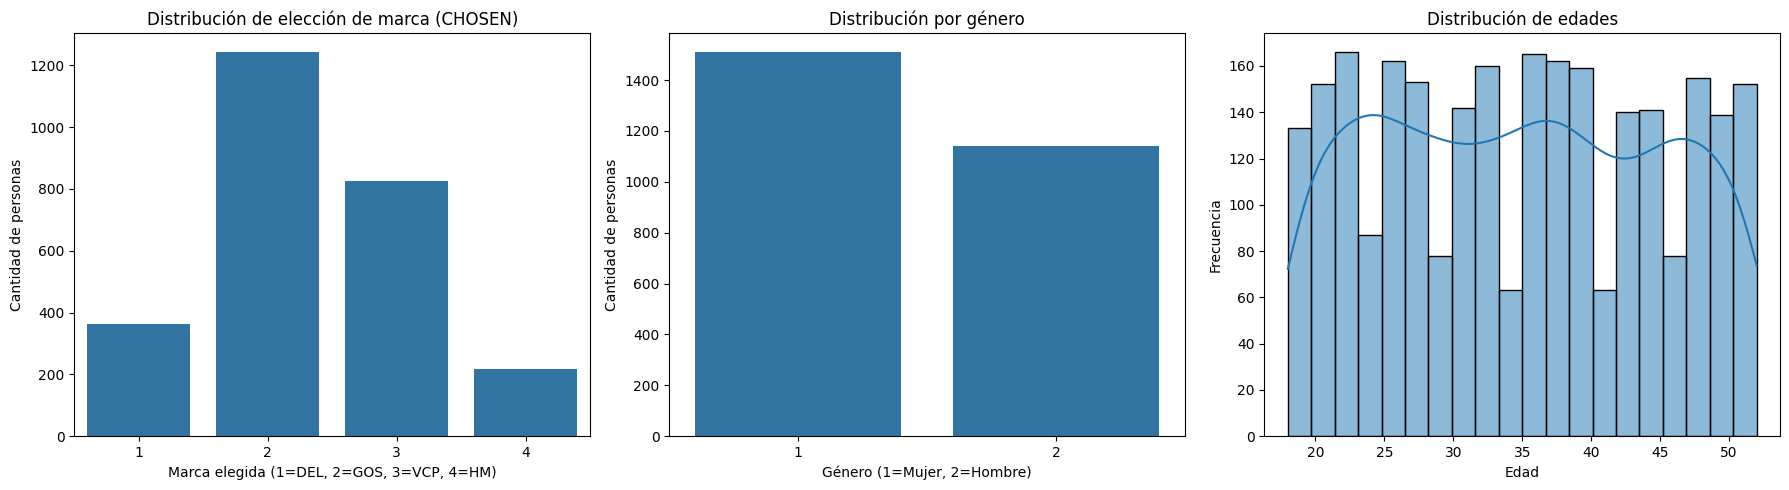

Estadísticas descriptivas clave:

               AGE       GENDER         GRAD       INCOME
count  2650.000000  2650.000000  2650.000000  2650.000000
mean     34.848679     1.430189     1.589057     1.907170
std      10.020107     0.495196     0.738184     0.804659
min      18.000000     1.000000     1.000000     1.000000
25%      26.000000     1.000000     1.000000     1.000000
50%      35.000000     1.000000     1.000000     2.000000
75%      44.000000     2.000000     2.000000     3.000000
max      52.000000     2.000000     3.000000     3.000000


In [7]:
# Crear gráficos de frecuencia para CHOSEN, GENDER y AGE
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Distribución de elección de marca
sns.countplot(x='CHOSEN', data=df, ax=axes[0])
axes[0].set_title('Distribución de elección de marca (CHOSEN)')
axes[0].set_xlabel('Marca elegida (1=DEL, 2=GOS, 3=VCP, 4=HM)')
axes[0].set_ylabel('Cantidad de personas')

# 2. Distribución por género
sns.countplot(x='GENDER', data=df, ax=axes[1])
axes[1].set_title('Distribución por género')
axes[1].set_xlabel('Género (1=Mujer, 2=Hombre)')
axes[1].set_ylabel('Cantidad de personas')

# 3. Histograma de edad
sns.histplot(df['AGE'], bins=20, kde=True, ax=axes[2])
axes[2].set_title('Distribución de edades')
axes[2].set_xlabel('Edad')
axes[2].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# Estadísticas descriptivas de edad, género, educación e ingresos
stats = df[['AGE', 'GENDER', 'GRAD', 'INCOME']].describe(include='all')
print("Estadísticas descriptivas clave:\n")
print(stats)

In [8]:
(df['GRAD'] >= 2).sum() / len(df)


0.4377358490566038

In [ ]:
# Atributos a considerar
atributos = ['KNOWN', 'BOTTLE', 'INFLAB', 'LAB', 'SMELL', 'COLOR', 'ADV']
marcas = {1: 'DEL', 2: 'GOS', 3: 'VCP', 4: 'HM'}

# Crear lista para los resultados
resultados = []

for codigo, marca in marcas.items():
    fila = {'Marca elegida': marca}
    df_marca = df[df['CHOSEN'] == codigo]
    for atributo in atributos:
        col = f"{atributo}_{marca}"
        if col in df.columns:
            fila[atributo] = round(df_marca[col].mean(), 2)
        else:
            fila[atributo] = 'No disponible'
    resultados.append(fila)

# Crear DataFrame con resultados
tabla_final = pd.DataFrame(resultados)
tabla_final = tabla_final.set_index('Marca elegida')

# Mostrar la tabla
print("\nPromedios de atributos por marca elegida:")
print(tabla_final)




Promedios de atributos por marca elegida:
               KNOWN  BOTTLE  INFLAB   LAB  SMELL  COLOR   ADV
Marca elegida                                                 
DEL             1.32    3.15    3.54  3.28   4.19   4.08  3.76
GOS             1.61    4.50    3.70  4.03   4.19   4.21  3.35
VCP             1.54    4.13    3.75  3.92   4.17   4.14  3.28
HM              1.25    2.74    3.57  2.82   4.12   4.09  3.32


In [ ]:
# Atributos a considerar
atributos = ['KNOWN', 'BOTTLE', 'INFLAB', 'LAB', 'SMELL', 'COLOR', 'ADV']
marcas = ['DEL', 'GOS', 'VCP', 'HM']

# Crear lista para los resultados
resultados_totales = []

for marca in marcas:
    fila = {'Marca': marca}
    for atributo in atributos:
        col = f"{atributo}_{marca}"
        if col in df.columns:
            fila[atributo] = round(df[col].mean(), 2)
        else:
            fila[atributo] = 'No disponible'
    resultados_totales.append(fila)

# Crear DataFrame con los resultados para toda la muestra
tabla_total = pd.DataFrame(resultados_totales)
tabla_total = tabla_total.set_index('Marca')

print("\nPromedios de atributos por marca (toda la muestra):")
print(tabla_total)


Promedios de atributos por marca (toda la muestra):
       KNOWN  BOTTLE  INFLAB   LAB  SMELL  COLOR   ADV
Marca                                                 
DEL     1.29    3.02    3.32  3.15   4.12   4.13  3.45
GOS     1.59    4.43    3.65  3.98   4.20   4.20  3.19
VCP     1.50    4.02    3.67  3.80   4.13   4.17  3.16
HM      1.24    2.68    3.42  2.75   4.11   4.06  3.14


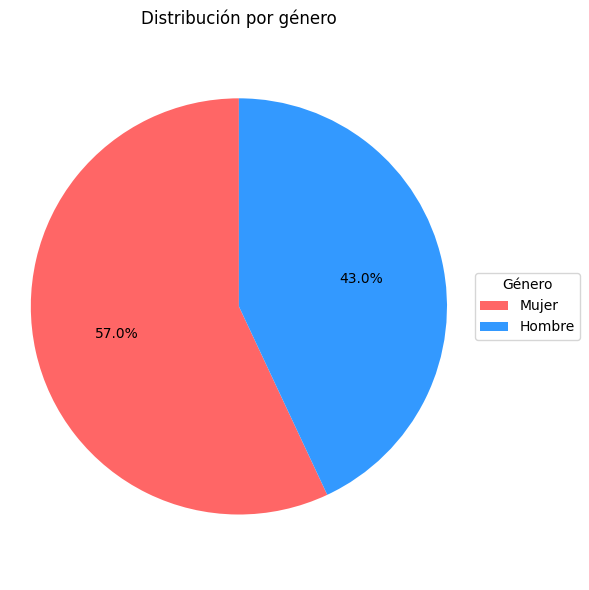

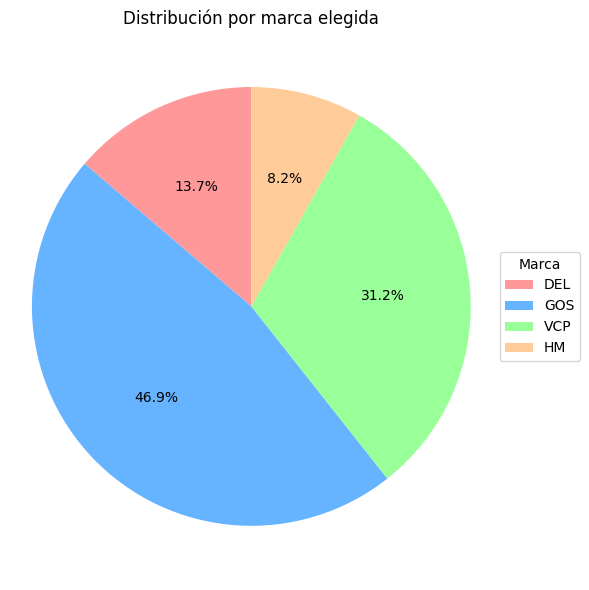

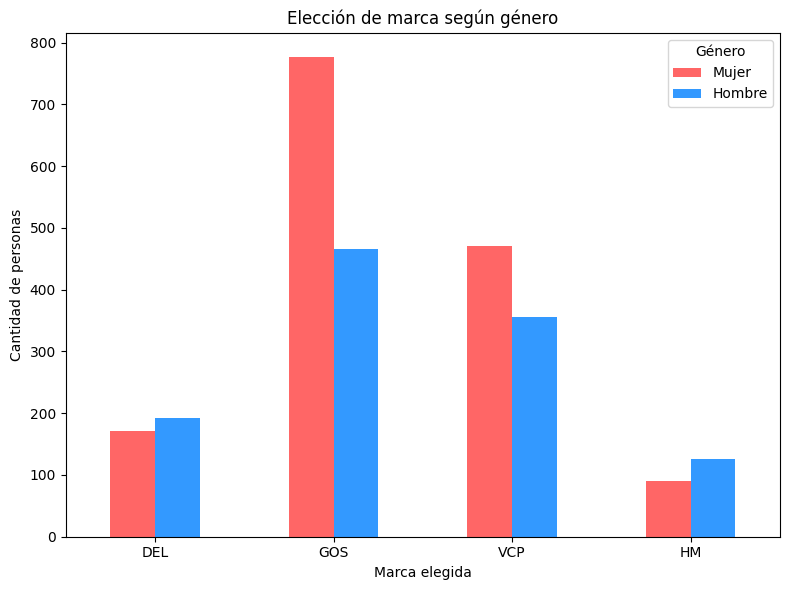

In [15]:
# 1. Gráfico de torta: distribución por género
gender_counts = df['GENDER'].value_counts().sort_index()
labels_gender = ['Mujer', 'Hombre']
colors_gender = ['#ff6666', '#3399ff']

fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    gender_counts,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors_gender,
    textprops=dict(color="black")
)
ax.set_title('Distribución por género')
ax.legend(wedges, labels_gender, title="Género", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
ax.axis('equal')
plt.tight_layout()
plt.show()

# 2. Gráfico de torta: distribución por marca elegida
brand_counts = df['CHOSEN'].value_counts().sort_index()
labels_brands = ['DEL', 'GOS', 'VCP', 'HM']
colors_brands = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']

fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    brand_counts,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors_brands,
    textprops=dict(color="black")
)
ax.set_title('Distribución por marca elegida')
ax.legend(wedges, labels_brands, title="Marca", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
ax.axis('equal')
plt.tight_layout()
plt.show()

# 3. Gráfico de barras agrupadas: elección de marca según género
gender_brand_counts = df.groupby(['CHOSEN', 'GENDER']).size().unstack()
gender_brand_counts.index = ['DEL', 'GOS', 'VCP', 'HM']
gender_brand_counts.columns = ['Mujer', 'Hombre']

ax = gender_brand_counts.plot(kind='bar', figsize=(8, 6), color=['#ff6666', '#3399ff'])
plt.title('Elección de marca según género')
plt.xlabel('Marca elegida')
plt.ylabel('Cantidad de personas')
plt.xticks(rotation=0)
plt.legend(title='Género')
plt.tight_layout()
plt.show()



In [16]:
# Suponiendo que ya cargaste correctamente el archivo con todas las columnas

brand_map = {1: 'DEL', 2: 'GOS', 3: 'VCP', 4: 'HM'}
resultados = []

for code, marca in brand_map.items():
    subset = df[df['CHOSEN'] == code]
    total = len(subset)
    if total > 0:
        resultados.append({
            'Marca escogida': marca,
            'Insta': round((subset['INSTA'] == 1).sum() / total, 2),
            'twitter': round((subset['TWITTER'] == 1).sum() / total, 2),
            'facebook': round((subset['FACEBOOK'] == 1).sum() / total, 2)
        })

tabla_redes = pd.DataFrame(resultados).set_index('Marca escogida')
print(tabla_redes)

                Insta  twitter  facebook
Marca escogida                          
DEL              0.24     0.35      0.50
GOS              0.23     0.33      0.51
VCP              0.21     0.35      0.49
HM               0.24     0.39      0.54


In [17]:
variables = ['WORK', 'GRAD', 'RELIG', 'STUDENT', 'MARRIED']
brand_map = {1: 'DEL', 2: 'GOS', 3: 'VCP', 4: 'HM'}
tablas_resultado = {}

for var in variables:
    resultados = []
    for code, marca in brand_map.items():
        subset = df[df['CHOSEN'] == code]
        total = len(subset)
        fila = {'Marca escogida': marca}
        if total > 0:
            for categoria in sorted(df[var].dropna().unique()):
                fila[f'{var}={int(categoria)}'] = round((subset[var] == categoria).sum() / total, 2)
        resultados.append(fila)
    tabla = pd.DataFrame(resultados).set_index('Marca escogida')
    tablas_resultado[var] = tabla

for nombre, tabla in tablas_resultado.items():
    print(f"\n{nombre}:\n")
    print(tabla)


WORK:

                WORK=1  WORK=2  WORK=3
Marca escogida                        
DEL               0.62    0.29    0.09
GOS               0.58    0.31    0.11
VCP               0.61    0.27    0.12
HM                0.59    0.29    0.12

GRAD:

                GRAD=1  GRAD=2  GRAD=3
Marca escogida                        
DEL               0.59    0.27    0.14
GOS               0.55    0.28    0.17
VCP               0.54    0.31    0.14
HM                0.64    0.24    0.12

RELIG:

                RELIG=1  RELIG=2  RELIG=3  RELIG=4
Marca escogida                                    
DEL                0.57     0.30     0.10     0.03
GOS                0.60     0.27     0.09     0.04
VCP                0.59     0.27     0.10     0.03
HM                 0.60     0.28     0.08     0.04

STUDENT:

                STUDENT=1  STUDENT=2  STUDENT=3
Marca escogida                                 
DEL                  0.54       0.29       0.17
GOS                  0.56       0.28       0.1

In [18]:
variables = ['INCOME', 'KIDS', 'ALONE', 'REGION', 'DENSIT', 'FREQ', 'DRINKER']
brand_map = {1: 'DEL', 2: 'GOS', 3: 'VCP', 4: 'HM'}
tablas_resultado = {}

for var in variables:
    resultados = []
    for code, marca in brand_map.items():
        subset = df[df['CHOSEN'] == code]
        total = len(subset)
        fila = {'Marca escogida': marca}
        if total > 0:
            for categoria in sorted(df[var].dropna().unique()):
                fila[f'{var}={int(categoria)}'] = round((subset[var] == categoria).sum() / total, 2)
        resultados.append(fila)
    tabla = pd.DataFrame(resultados).set_index('Marca escogida')
    tablas_resultado[var] = tabla

for nombre, tabla in tablas_resultado.items():
    print(f"\n{nombre}:\n")
    print(tabla)




INCOME:

                INCOME=1  INCOME=2  INCOME=3
Marca escogida                              
DEL                 0.42      0.32      0.26
GOS                 0.36      0.33      0.32
VCP                 0.36      0.37      0.26
HM                  0.44      0.38      0.18

KIDS:

                KIDS=1  KIDS=2
Marca escogida                
DEL               0.30    0.70
GOS               0.29    0.71
VCP               0.33    0.67
HM                0.33    0.67

ALONE:

                ALONE=1  ALONE=2
Marca escogida                  
DEL                0.18     0.82
GOS                0.18     0.82
VCP                0.21     0.79
HM                 0.23     0.77

REGION:

                REGION=1  REGION=2  REGION=5  REGION=6  REGION=7  REGION=8  \
Marca escogida                                                               
DEL                 0.20      0.03      0.04      0.06      0.09      0.12   
GOS                 0.26      0.05      0.04      0.07      0.09      0.08 

In [19]:
# Diccionarios de texto para mostrar en tabla
gender_map = {1: 'Mujer', 2: 'Hombre'}
kids_map = {1: 'Tiene hijos', 2: 'No tiene hijos'}
brand_map = {1: 'DEL', 2: 'GOS', 3: 'VCP', 4: 'HM'}

# Lista de resultados
resultados = []

# Recorrer cada marca
for code, marca in brand_map.items():
    subset = df[df['CHOSEN'] == code]
    total = len(subset)
    if total > 0:
        for g in [1, 2]:
            for k in [1, 2]:
                count = ((subset['GENDER'] == g) & (subset['KIDS'] == k)).sum()
                porcentaje = round(count / total, 2)
                resultados.append({
                    'Marca': marca,
                    'Género': gender_map[g],
                    'Hijos': kids_map[k],
                    'Porcentaje': porcentaje
                })

# Crear DataFrame final
tabla_cruzada = pd.DataFrame(resultados)
print(tabla_cruzada)



   Marca  Género           Hijos  Porcentaje
0    DEL   Mujer     Tiene hijos        0.13
1    DEL   Mujer  No tiene hijos        0.34
2    DEL  Hombre     Tiene hijos        0.16
3    DEL  Hombre  No tiene hijos        0.37
4    GOS   Mujer     Tiene hijos        0.18
5    GOS   Mujer  No tiene hijos        0.44
6    GOS  Hombre     Tiene hijos        0.11
7    GOS  Hombre  No tiene hijos        0.27
8    VCP   Mujer     Tiene hijos        0.19
9    VCP   Mujer  No tiene hijos        0.38
10   VCP  Hombre     Tiene hijos        0.14
11   VCP  Hombre  No tiene hijos        0.29
12    HM   Mujer     Tiene hijos        0.17
13    HM   Mujer  No tiene hijos        0.25
14    HM  Hombre     Tiene hijos        0.16
15    HM  Hombre  No tiene hijos        0.42


In [20]:
# Crear tabla de distribución de género por marca elegida
tabla_genero_marca = df.groupby(['CHOSEN', 'GENDER']).size().unstack().fillna(0)

# Renombrar índices y columnas para mayor claridad
tabla_genero_marca.index = ['DEL', 'GOS', 'VCP', 'HM']
tabla_genero_marca.columns = ['Mujer', 'Hombre']

print(tabla_genero_marca)


     Mujer  Hombre
DEL    171     193
GOS    777     466
VCP    471     355
HM      91     126


In [21]:
# Mapeo de marcas a sus precios fijos en el dataset
precios = {
    'DEL': df['PRICE_DEL'].iloc[0],
    'GOS': df['PRICE_GOS'].iloc[0],
    'VCP': df['PRICE_VCP'].iloc[0],
    'HM': df['PRICE_HM'].iloc[0]
}

# Mapeo de códigos de ingreso a valores representativos
ingreso_estimado = {
    1: 10000,   # Menos de 15.000
    2: 22500,   # Entre 15.000 y 30.000
    3: 40000    # Más de 30.000
}

# Calcular ingreso promedio estimado por marca elegida
promedios = {}
for code, marca in {1: 'DEL', 2: 'GOS', 3: 'VCP', 4: 'HM'}.items():
    subset = df[df['CHOSEN'] == code]
    ingresos = subset['INCOME'].map(ingreso_estimado)
    ingreso_promedio = ingresos.mean()
    precio = precios[marca]
    promedios[marca] = {'Ingreso promedio (€)': round(ingreso_promedio, 2), 'Precio (€)': precio}

# Convertir a DataFrame para visualización
tabla_ingreso_precio = pd.DataFrame(promedios).T
print(tabla_ingreso_precio)


    Ingreso promedio (€) Precio (€)
DEL             21730.77      15,85
GOS             23602.17      27,35
VCP             22563.56      20,88
HM              20253.46       12,5


In [24]:
marcas = ['DEL', 'GOS', 'VCP', 'HM']
atributos = ['BOTTLE', 'INFLAB', 'LAB', 'SMELL', 'COLOR', 'ADV']
code_map = {'DEL': 1, 'GOS': 2, 'VCP': 3, 'HM': 4}
tablas_comparativas = {}

for marca_elegida in marcas:
    code = code_map[marca_elegida]
    subset = df[df['CHOSEN'] == code]
    fila_resultado = {}

    for marca_eval in marcas:
        fila = {}
        for atributo in atributos:
            col = f'{atributo}_{marca_eval}'
            if col in df.columns:
                fila[atributo] = round(subset[col].mean(), 2)
            else:
                fila[atributo] = None
        fila_resultado[marca_eval] = fila

    tabla = pd.DataFrame(fila_resultado).T
    tabla.index.name = 'Marca evaluada'
    tabla['Promedio'] = tabla.mean(axis=1).round(2)
    tablas_comparativas[marca_elegida] = tabla

for marca, tabla in tablas_comparativas.items():
    print(f"\nEvaluaciones hechas por quienes eligieron {marca}:\n")
    print(tabla)




Evaluaciones hechas por quienes eligieron DEL:

                BOTTLE  INFLAB   LAB  SMELL  COLOR   ADV  Promedio
Marca evaluada                                                    
DEL               3.15    3.54  3.28   4.19   4.08  3.76      3.67
GOS               4.26    3.57  3.88   4.29   4.21  3.00      3.87
VCP               4.03    3.69  3.75   4.13   4.19  3.16      3.83
HM                2.71    3.38  2.72   4.09   4.12  3.04      3.34

Evaluaciones hechas por quienes eligieron GOS:

                BOTTLE  INFLAB   LAB  SMELL  COLOR   ADV  Promedio
Marca evaluada                                                    
DEL               3.01    3.27  3.12   4.10   4.14  3.37      3.50
GOS               4.50    3.70  4.03   4.19   4.21  3.35      4.00
VCP               3.96    3.64  3.74   4.10   4.17  3.07      3.78
HM                2.69    3.44  2.73   4.10   4.06  3.17      3.36

Evaluaciones hechas por quienes eligieron VCP:

                BOTTLE  INFLAB   LAB  SMELL  COLO

In [29]:
# Mapeo de ingreso a euros
ingreso_estimado = {
    1: 10000,
    2: 22500,
    3: 40000
}

# Mapeo código marca → columna de precio
precio_cols = {
    1: 'PRICE_DEL',
    2: 'PRICE_GOS',
    3: 'PRICE_VCP',
    4: 'PRICE_HM'
}

# Crear copia del DataFrame y mapear ingresos
df_ing_precio = df.copy()
df_ing_precio['Ingreso estimado'] = df_ing_precio['INCOME'].map(ingreso_estimado)

# Limpiar y convertir precios
def extraer_precio(row):
    valor = row[precio_cols[row['CHOSEN']]]
    if isinstance(valor, str):
        valor = valor.replace(',', '.')
    return float(valor)

df_ing_precio['Precio elegido'] = df_ing_precio.apply(extraer_precio, axis=1)

# Asegurar que las columnas sean numéricas
df_ing_precio['Ingreso estimado'] = pd.to_numeric(df_ing_precio['Ingreso estimado'], errors='coerce')
df_ing_precio['Precio elegido'] = pd.to_numeric(df_ing_precio['Precio elegido'], errors='coerce')

# Agrupar y mostrar resumen
resumen = df_ing_precio.groupby('CHOSEN')[['Ingreso estimado', 'Precio elegido']].mean().round(2)
resumen.index = ['DEL', 'GOS', 'VCP', 'HM']

print("\nPromedio de ingreso y precio pagado según marca elegida:")
print(resumen)



Promedio de ingreso y precio pagado según marca elegida:
     Ingreso estimado  Precio elegido
DEL          21730.77           15.85
GOS          23602.17           27.35
VCP          22563.56           20.88
HM           20253.46           12.50


In [27]:
# Inicializar resultados
import numpy as np

marcas = ['DEL', 'GOS', 'VCP', 'HM']
atributos = ['BOTTLE', 'INFLAB', 'LAB', 'SMELL', 'COLOR', 'ADV']
drinker_grupos = sorted(df['DRINKER'].dropna().unique())
code_map = {'DEL': 1, 'GOS': 2, 'VCP': 3, 'HM': 4}

# Diccionario de resultados
resultados_drinker = {}

# Calcular promedio de calificación dada a la marca elegida, por nivel DRINKER
for grupo in drinker_grupos:
    subset = df[df['DRINKER'] == grupo]
    promedio_por_marca = {}
    for marca in marcas:
        code = code_map[marca]
        subsub = subset[subset['CHOSEN'] == code]
        valores = []
        for atributo in atributos:
            col = f'{atributo}_{marca}'
            if col in df.columns:
                valores.append(subsub[col].mean())
        if valores:
            promedio_por_marca[marca] = round(np.nanmean(valores), 2)
    resultados_drinker[f'DRINKER={grupo}'] = promedio_por_marca

# Convertir a DataFrame
tabla_drinker = pd.DataFrame(resultados_drinker).T
print("\nPromedio de calificación a la marca elegida según nivel DRINKER:")
print(tabla_drinker)



Promedio de calificación a la marca elegida según nivel DRINKER:
            DEL   GOS   VCP    HM
DRINKER=1  3.73  4.00  3.91  3.37
DRINKER=2  3.58  4.00  3.86  3.51
DRINKER=3  3.68  3.98  3.91  3.50
DRINKER=4  3.67  4.05  3.94  3.27


In [30]:
# Marcas y atributos
marcas = ['DEL', 'GOS', 'VCP', 'HM']
atributos = ['BOTTLE', 'INFLAB', 'LAB', 'SMELL', 'COLOR', 'ADV']

# Calcular el promedio de atributos por marca para cada persona
for marca in marcas:
    cols = [f"{atributo}_{marca}" for atributo in atributos]
    df[f'PROMEDIO_{marca}'] = df[cols].mean(axis=1)

# Identificar la marca con mayor promedio de calificación por persona
df['MEJOR_CALIFICADA'] = df[[f'PROMEDIO_{m}' for m in marcas]].idxmax(axis=1).str.replace('PROMEDIO_', '')

# Identificar la marca elegida (CHOSEN) con su nombre
mapa = {1: 'DEL', 2: 'GOS', 3: 'VCP', 4: 'HM'}
df['MARCA_ELEGIDA'] = df['CHOSEN'].map(mapa)

# Verificar coincidencia
df['COINCIDE'] = df['MEJOR_CALIFICADA'] == df['MARCA_ELEGIDA']

# Calcular tasa general de coincidencia
tasa_total = df['COINCIDE'].mean().round(2)

# Tasa por nivel DRINKER (u otro si lo deseas)
tasa_por_drinker = df.groupby('DRINKER')['COINCIDE'].mean().round(2)

print(f"\n📊 Porcentaje general de individuos que eligieron la marca que mejor calificaron: {tasa_total * 100}%")
print("\n📊 Porcentaje por nivel de conocimiento (DRINKER):")
print(tasa_por_drinker)



📊 Porcentaje general de individuos que eligieron la marca que mejor calificaron: 41.0%

📊 Porcentaje por nivel de conocimiento (DRINKER):
DRINKER
1    0.42
2    0.39
3    0.42
4    0.44
Name: COINCIDE, dtype: float64


In [31]:
# Paso 1: Para cada persona, obtener el promedio de la marca que eligió
df['PROMEDIO_ELEGIDA'] = df.apply(lambda row: row[f"PROMEDIO_{row['MARCA_ELEGIDA']}"], axis=1)

# Paso 2: Para cada persona, obtener el promedio de la marca mejor calificada
df['PROMEDIO_MEJOR'] = df.apply(lambda row: row[f"PROMEDIO_{row['MEJOR_CALIFICADA']}"], axis=1)

# Paso 3: Calcular diferencia (sacrificio)
df['DIFERENCIA'] = (df['PROMEDIO_MEJOR'] - df['PROMEDIO_ELEGIDA']).round(2)

# Paso 4: Filtrar solo los casos donde no coincidió
sacrificio_df = df[df['COINCIDE'] == False]

# Paso 5: Resumen general
media_sacrificio = sacrificio_df['DIFERENCIA'].mean().round(2)
mediana_sacrificio = sacrificio_df['DIFERENCIA'].median().round(2)

# Paso 6: Sacrificio promedio por nivel DRINKER (opcional)
sacrificio_por_drinker = sacrificio_df.groupby('DRINKER')['DIFERENCIA'].mean().round(2)

# Resultados
print(f"\n📉 Promedio de sacrificio de evaluación entre quienes NO eligieron su marca mejor calificada: {media_sacrificio}")
print(f"📉 Mediana del sacrificio: {mediana_sacrificio}")
print("\n📊 Sacrificio promedio por nivel DRINKER:")
print(sacrificio_por_drinker)



📉 Promedio de sacrificio de evaluación entre quienes NO eligieron su marca mejor calificada: 0.49
📉 Mediana del sacrificio: 0.5

📊 Sacrificio promedio por nivel DRINKER:
DRINKER
1    0.50
2    0.51
3    0.46
4    0.49
Name: DIFERENCIA, dtype: float64


In [32]:
# Cambiar esta línea para probar con otras variables
variable = 'INCOME'

# Filtrar solo quienes no coincidieron
sacrificio_df = df[df['COINCIDE'] == False]

# Calcular sacrificio promedio por grupo
sacrificio_por_variable = sacrificio_df.groupby(variable)['DIFERENCIA'].mean().round(2)

print(f"\n📊 Sacrificio promedio por grupo de {variable}:")
print(sacrificio_por_variable)



📊 Sacrificio promedio por grupo de INCOME:
INCOME
1    0.51
2    0.49
3    0.46
Name: DIFERENCIA, dtype: float64


In [35]:
# Cambia esta variable según el análisis
variable = 'GENDER'  # o 'FREQ', 'GRAD', etc.

# Filtrar quienes no eligieron su marca mejor calificada
sacrificio_df = df[df['COINCIDE'] == False]

# Calcular promedio de sacrificio por categoría
sacrificio_por_variable = sacrificio_df.groupby(variable)['DIFERENCIA'].mean().round(2)

print(f"\n📊 Sacrificio promedio por grupo de {variable}:")
print(sacrificio_por_variable)



# Cambia esta variable según el análisis
variable = 'FREQ'  # o 'FREQ', 'GRAD', etc.

# Filtrar quienes no eligieron su marca mejor calificada
sacrificio_df = df[df['COINCIDE'] == False]

# Calcular promedio de sacrificio por categoría
sacrificio_por_variable = sacrificio_df.groupby(variable)['DIFERENCIA'].mean().round(2)

print(f"\n📊 Sacrificio promedio por grupo de {variable}:")
print(sacrificio_por_variable)


# Cambia esta variable según el análisis
variable = 'GRAD'  # o 'FREQ', 'GRAD', etc.

# Filtrar quienes no eligieron su marca mejor calificada
sacrificio_df = df[df['COINCIDE'] == False]

# Calcular promedio de sacrificio por categoría
sacrificio_por_variable = sacrificio_df.groupby(variable)['DIFERENCIA'].mean().round(2)

print(f"\n📊 Sacrificio promedio por grupo de {variable}:")
print(sacrificio_por_variable)


# Cambia esta variable según el análisis
variable = 'WORK'  # o 'FREQ', 'GRAD', etc.

# Filtrar quienes no eligieron su marca mejor calificada
sacrificio_df = df[df['COINCIDE'] == False]

# Calcular promedio de sacrificio por categoría
sacrificio_por_variable = sacrificio_df.groupby(variable)['DIFERENCIA'].mean().round(2)

print(f"\n📊 Sacrificio promedio por grupo de {variable}:")
print(sacrificio_por_variable)


# Cambia esta variable según el análisis
variable = 'AGE'  # o 'FREQ', 'GRAD', etc.

# Filtrar quienes no eligieron su marca mejor calificada
sacrificio_df = df[df['COINCIDE'] == False]

# Calcular promedio de sacrificio por categoría
sacrificio_por_variable = sacrificio_df.groupby(variable)['DIFERENCIA'].mean().round(2)

print(f"\n📊 Sacrificio promedio por grupo de {variable}:")
print(sacrificio_por_variable)



📊 Sacrificio promedio por grupo de GENDER:
GENDER
1    0.47
2    0.52
Name: DIFERENCIA, dtype: float64

📊 Sacrificio promedio por grupo de FREQ:
FREQ
1    0.51
2    0.46
Name: DIFERENCIA, dtype: float64

📊 Sacrificio promedio por grupo de GRAD:
GRAD
1    0.50
2    0.48
3    0.49
Name: DIFERENCIA, dtype: float64

📊 Sacrificio promedio por grupo de WORK:
WORK
1    0.49
2    0.50
3    0.47
Name: DIFERENCIA, dtype: float64

📊 Sacrificio promedio por grupo de AGE:
AGE
18    0.62
19    0.60
20    0.48
21    0.60
22    0.45
23    0.41
24    0.48
25    0.55
26    0.45
27    0.52
28    0.46
29    0.45
30    0.56
31    0.43
32    0.55
33    0.42
34    0.38
35    0.48
36    0.57
37    0.42
38    0.44
39    0.61
40    0.41
41    0.53
42    0.53
43    0.54
44    0.50
45    0.51
46    0.41
47    0.49
48    0.43
49    0.55
50    0.48
51    0.47
52    0.42
Name: DIFERENCIA, dtype: float64
